# **UTS INTEGRASI DATA**
**Data Matching**

Tugas ini dibangun untuk mendeteksi anomali pada data Pengadaan Barang/Jasa (PBJ) menggunakan pendekatan klasifikasi berbobot. Dimulai dari pre-processing dan pelabelan berbasis kemiripan nama paket, dilanjutkan klasifikasi dengan Weighted Scoring dan XGBoost, hingga visualisasi anomali anggaran dan metode pengadaan.


**Disusun Oleh**
| Nama | Chayun Fadila |
|------|---------------|
| **NRP**  | **602624211**     |

In [ ]:
!pip install xgboost scikit-learn pandas matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

print('✅ Library siap!')


✅ Library siap!


In [3]:
# ⚠️ Sesuaikan path jika berbeda
FILE_PATH = 'hasil_filter_bbm.csv'

df = pd.read_csv(FILE_PATH, encoding='utf-8', on_bad_lines='skip')
df = df.dropna(subset=['pagu']).reset_index(drop=True)

print(f'Shape  : {df.shape}')
print(f'Kolom  : {df.columns.tolist()}')
df.head(3)

Shape  : (78939, 21)
Kolom  : ['paket', 'dalamNegeri', 'jenisPengadaan', 'metode', 'lembaga', 'satker', 'lokasi', 'id', 'pagu', 'pemilihanDate', 'sumberDana', 'isUMKM', 'volumePekerjaan', 'uraianPekerjaan', 'spesifikasiPekerjaan', 'ownerType', 'potensiPemborosan', 'tags.isInappropriate', 'tags.inappropriateReason', 'jumlahTagAktif', '_source_part']


,paket,dalamNegeri,jenisPengadaan,metode,lembaga,satker,lokasi,id,pagu,pemilihanDate,...,isUMKM,volumePekerjaan,uraianPekerjaan,spesifikasiPekerjaan,ownerType,potensiPemborosan,tags.isInappropriate,tags.inappropriateReason,jumlahTagAktif,_source_part
0,Pemeliharaan Kendaraan Dinas Operasional Roda ...,True,Jasa Lainnya,Penunjukan Langsung,"Badan Meteorologi, Klimatologi Dan Geofisika",Stasiun Geofisika Kelas I Kupang,"Nusa Tenggara Timur, Kupang (Kota)",62200988,36000000.0,January 2026,...,True,"( 1, UNIT, @ 36000000 )",1. Pemeliharaan Kendaraan Dinas Operasional Ro...,Pemeliharaan Kendaraan Dinas Operasional Roda ...,central,0.0,low,NaN,0,1
1,Pemeliharaan Kendaraan Dinas Operasional Roda 2,True,Barang,Pengadaan Langsung,"Badan Meteorologi, Klimatologi Dan Geofisika",Stasiun Meteorologi Kelas III Dabo Lingga,"Kepulauan Riau, Lingga (Kab.)",62197498,13500000.0,January 2026,...,True,"( 3, UNIT, @ 4500000 )",1. Pemeliharaan Kendaraan Dinas Operasional Ro...,Pembelian Bensin Pembelian Ban servis Komponen...,central,0.0,low,NaN,0,1
2,Belanja Pemeliharaan Alat Angkutan-Alat Angkut...,True,Jasa Lainnya,Pengadaan Langsung,Kab. Gresik,DINAS PERTANIAN,"Jawa Timur, Gresik (Kab.)",62300809,4970000.0,January 2026,...,True,1 Paket,B.1.SBU.197-Pemeliharaan Kendaraan Dinas Opera...,Roda 2 (termasuk BBM tidak termasuk overhaul);,kabkota,0.0,low,NaN,0,1


## ⚙️ Konfigurasi & Bobot

> - `Nama Paket = 0.50` → identitas utama paket, paling dominan
> - `Uraian Pekerjaan = 0.35` → detail teknis, membedakan paket yg namanya mirip tapi isinya beda
> - `Metode Pengadaan = 0.15` → konteks prosedural, penting tapi bukan penentu utama

| Kolom | Bobot | Alasan |
|---|---|---|
| **Nama Paket** | **50%** | Identitas utama paket pengadaan. Jika nama mirip → kemungkinan besar paket serupa |
| **Uraian Pekerjaan** | **35%** | Detail teknis yang membedakan paket bermakna sama vs berbeda konteks |
| **Metode Pengadaan** | **15%** | Konteks prosedural. Dua paket bisa mirip walau metode berbeda, tapi tetap relevan |


In [4]:
# === BOBOT WEIGHTED SCORING ===
W_PAKET  = 0.50
W_URAIAN = 0.35
W_METODE = 0.15

# === THRESHOLD ===
THRESHOLD_SIM_PAKET = 0.80   # sim nama paket >= 80% -> zona semi-manual
THRESHOLD_LABEL     = 0.65   # weighted score >= 0.65 -> label MIRIP
BUDGET_ANOMALY_PCT  = 50     # selisih pagu > 50% -> anomali anggaran

# === SAMPLING ===
SAMPLE_SIZE = 2000

print(f'Bobot: Nama Paket={W_PAKET} | Uraian={W_URAIAN} | Metode={W_METODE}')
print(f'Total bobot = {W_PAKET+W_URAIAN+W_METODE}')


Bobot: Nama Paket=0.5 | Uraian=0.35 | Metode=0.15
Total bobot = 1.0


---
## 🧹 Pre-processing & Similarity Labelling

In [5]:
def normalize(text):
    if not isinstance(text, str): return ''
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['paket_norm']  = df['paket'].apply(normalize)
df['uraian_norm'] = df['uraianPekerjaan'].apply(normalize)

print('Contoh normalisasi:')
for i in range(3):
    print(f'  Ori  : {df["paket"].iloc[i][:70]}')
    print(f'  Norm : {df["paket_norm"].iloc[i][:70]}')
    print()

Contoh normalisasi:
  Ori  : Pemeliharaan Kendaraan Dinas Operasional Roda 4 (Double Gardan)
  Norm : pemeliharaan kendaraan dinas operasional roda 4 double gardan

  Ori  : Pemeliharaan Kendaraan Dinas Operasional Roda 2
  Norm : pemeliharaan kendaraan dinas operasional roda 2

  Ori  : Belanja Pemeliharaan Alat Angkutan-Alat Angkutan Darat Bermotor-Kendar
  Norm : belanja pemeliharaan alat angkutan alat angkutan darat bermotor kendar



### Sampling Data Unik

In [6]:
df_rep = df.drop_duplicates(subset='paket_norm').reset_index(drop=True)
print(f'Total baris         : {len(df):,}')
print(f'Nama paket unik     : {len(df_rep):,}')

np.random.seed(42)
idx  = np.random.choice(len(df_rep), size=min(SAMPLE_SIZE, len(df_rep)), replace=False)
df_s = df_rep.iloc[idx].reset_index(drop=True)
n    = len(df_s)
print(f'Sample digunakan    : {n:,}')


Total baris         : 78,939
Nama paket unik     : 26,785
Sample digunakan    : 2,000


### Cosine Similarity

similarity **hanya dihitung pada kolom `paket` (nama paket saja)**.
> Kolom uraian & metode baru digunakan pada saat tahap B sebagai fitur XGBoost.


In [7]:
# --- Similarity NAMA PAKET saja (untuk labelling) ---
print('Menghitung TF-IDF Cosine Similarity nama paket...')
tfidf_p = TfidfVectorizer(analyzer='word', ngram_range=(1,2))
pm      = tfidf_p.fit_transform(df_s['paket_norm'])
sim_p   = cosine_similarity(pm)

# --- Similarity URAIAN (hanya untuk fitur XGBoost, BUKAN untuk labelling) ---
print('Menghitung TF-IDF Uraian Pekerjaan (fitur XGBoost)...')
tfidf_u = TfidfVectorizer(analyzer='word', ngram_range=(1,2))
um      = tfidf_u.fit_transform(df_s['uraian_norm'])
sim_u   = cosine_similarity(um)

print('✅ Selesai!')


Menghitung TF-IDF Cosine Similarity nama paket...
Menghitung TF-IDF Uraian Pekerjaan (fitur XGBoost)...
✅ Selesai!


### Pairs DataFrame

In [8]:
print('Membangun pairs dataframe...')
pairs = []
for i in range(n):
    for j in range(i+1, n):
        sp = float(sim_p[i][j])
        if sp >= 0.5:
            pairs.append({'ia':i,'ib':j,'sim_paket':round(sp,4)})

pairs_df = pd.DataFrame(pairs)
print(f'Pasang (sim >= 0.5) : {len(pairs_df):,}')
print(f'Pasang (sim >= 0.8) : {(pairs_df["sim_paket"]>=0.8).sum():,}  ← zona semi-manual')


Membangun pairs dataframe...
Pasang (sim >= 0.5) : 2,551
Pasang (sim >= 0.8) : 124  ← zona semi-manual


### Fitur Tiap Pasang

In [9]:
pairs_df['sim_uraian']   = pairs_df.apply(lambda r: round(float(sim_u[int(r.ia)][int(r.ib)]),4), axis=1)
pairs_df['metode_a']     = pairs_df['ia'].map(lambda x: df_s.loc[x,'metode'])
pairs_df['metode_b']     = pairs_df['ib'].map(lambda x: df_s.loc[x,'metode'])
pairs_df['metode_match'] = (pairs_df['metode_a'] == pairs_df['metode_b']).astype(int)
pairs_df['pagu_a']       = pairs_df['ia'].map(lambda x: df_s.loc[x,'pagu'])
pairs_df['pagu_b']       = pairs_df['ib'].map(lambda x: df_s.loc[x,'pagu'])
pairs_df['pagu_ratio']   = pairs_df.apply(
    lambda r: min(r.pagu_a,r.pagu_b)/max(r.pagu_a,r.pagu_b) if max(r.pagu_a,r.pagu_b)>0 else 0, axis=1)
pairs_df['paket_a']      = pairs_df['ia'].map(lambda x: df_s.loc[x,'paket'])
pairs_df['paket_b']      = pairs_df['ib'].map(lambda x: df_s.loc[x,'paket'])
pairs_df.head(3)


,ia,ib,sim_paket,sim_uraian,metode_a,metode_b,metode_match,pagu_a,pagu_b,pagu_ratio,paket_a,paket_b
0,2,47,0.6061,0.0796,Dikecualikan,Pengadaan Langsung,0,49500000.0,200000000.0,0.247500,Belanja Pemeliharaan Kendaraan Operasional Lap...,pemeliharaan kendaraan operasional
1,2,909,0.6427,0.0000,Dikecualikan,Dikecualikan,1,49500000.0,81600000.0,0.606618,Belanja Pemeliharaan Kendaraan Operasional Lap...,Belanja Pemeliharaan Kendaraan Dinas Operasion...
2,6,746,0.5057,0.0848,Dikecualikan,E-Purchasing,0,1375000.0,70797650.0,0.019422,Belanja Bahan-Bahan Bakar dan Pelumas (BBM sos...,Belanja Bahan-Bahan Bakar dan Pelumas - BBM K...


### Semi-Manual Labelling

- Hitung **weighted score** dari 3 kolom
- Label `MIRIP=1` jika `weighted_score >= 0.65` **AND** `sim_paket >= 0.80`
- Di bawah 80% → otomatis `Tidak Mirip=0`
- Spot-check manual dilakukan pada sampel acak zona ≥80%


In [10]:
pairs_df['weighted_score'] = (
    W_PAKET  * pairs_df['sim_paket']  +
    W_URAIAN * pairs_df['sim_uraian'] +
    W_METODE * pairs_df['metode_match']
)

pairs_df['label'] = (
    (pairs_df['weighted_score'] >= THRESHOLD_LABEL) &
    (pairs_df['sim_paket']      >= THRESHOLD_SIM_PAKET)
).astype(int)

print('Label distribution:')
print(pairs_df['label'].value_counts().rename({0:'Tidak Mirip', 1:'Mirip'}))

# Spot check manual
print('\n--- Spot Check: Sampel Acak dari Zona >=80% ---')
spot = pairs_df[pairs_df['sim_paket'] >= 0.8].sample(min(10, len(pairs_df)), random_state=42)
for _, row in spot.iterrows():
    status = '✅ MIRIP' if row['label']==1 else '❌ TIDAK'
    print(f'  [{status}] sim={row["sim_paket"]:.2f} | {str(row["paket_a"])[:45]} <-> {str(row["paket_b"])[:45]}')


Label distribution:
label
Tidak Mirip    2498
Mirip            53
Name: count, dtype: int64

--- Spot Check: Sampel Acak dari Zona >=80% ---
  [❌ TIDAK] sim=0.84 | Belanja Bahan-Bahan Bakar dan Pelumas (Bahan  <-> Belanja Bahan Bakar-Bahan Bakar dan Pelumas (
  [❌ TIDAK] sim=0.92 | Belanja Bahan-Bahan Bakar dan Pelumas Sub Keg <-> Belanja Bahan-Bahan Bakar dan Pelumas (Pelaks
  [✅ MIRIP] sim=0.89 | Helper Petugas Operasional Lapangan (Pemadam  <-> Helper Petugas Operasional Lapangan (Pemadam 
  [❌ TIDAK] sim=0.89 | Biaya Bahan Bakar Minyak dan Service Mobil Pe <-> Biaya Bahan Bakar Minyak dan Service Mobil Pe
  [❌ TIDAK] sim=0.84 | Belanja Pemeliharaan Alat Angkutan-Alat Angku <-> Belanja Pemeliharaan Alat Angkutan-Alat Angku
  [❌ TIDAK] sim=0.86 | Pertamax Penyediaan Jasa Pemeliharaan, Biaya  <-> BBM Kegiatan Penyediaan Jasa Pemeliharaan, Bi
  [❌ TIDAK] sim=0.84 | Belanja Pemeliharaan Alat Angkutan-Alat Angku <-> Belanja Pemeliharaan Alat Angkutan-Alat Angku
  [✅ MIRIP] sim=0.81 | Bia

In [11]:
spot = pairs_df[pairs_df['sim_paket'] >= 0.8].sample(min(10, len(pairs_df)), random_state=42)

print('--- Spot Check Lengkap ---\n')
for idx, row in spot.iterrows():
    status = '✅ MIRIP' if row['label']==1 else '❌ TIDAK'
    print(f'index={idx} | [{status}] sim={row["sim_paket"]:.2f} | ws={row["weighted_score"]:.2f}')
    print(f'  Paket A : {str(row["paket_a"])}')
    print(f'  Paket B : {str(row["paket_b"])}')
    print(f'  Metode  : {row["metode_a"]} | {row["metode_b"]}')
    print(f'  Pagu    : Rp {row["pagu_a"]:,.0f} | Rp {row["pagu_b"]:,.0f}')
    print()

--- Spot Check Lengkap ---

index=544 | [❌ TIDAK] sim=0.84 | ws=0.57
  Paket A : Belanja Bahan-Bahan Bakar dan Pelumas (Bahan Bakar Minyak)-Penyediaan Jasa Pemeliharaan, Biaya Pemeliharaan, Pajak dan Perizinan Kendaraan Dinas Operasional atau Lapangan
  Paket B : Belanja Bahan Bakar-Bahan Bakar dan Pelumas (Penyediaan Jasa Pemeliharaan, Biaya Pemeliharaan, Pajak dan Perizinan Kendaraan Dinas Operasional atau Lapangan)
  Metode  : Dikecualikan | Dikecualikan
  Pagu    : Rp 101,918,050 | Rp 480,000

index=826 | [❌ TIDAK] sim=0.92 | ws=0.61
  Paket A : Belanja Bahan-Bahan Bakar dan Pelumas Sub Kegiatan Pelaksanaan Koordinasi di Bidang Kewaspadaan Dini, Kerja Sama Intelijen, Pemantauan Orang Asing, Tenaga Kerja Asing dan Lembaga Asing, Kewaspadaan Perbatasan antar Negara, Fasilitasi Kelembagaan Bidang Kewaspadaan, serta Penanganan Konflik di Daerah
  Paket B : Belanja Bahan-Bahan Bakar dan Pelumas (Pelaksanaan Monitoring, Evaluasi dan Pelaporan di Bidang Kewaspadaan Dini, Kerja Sama Inteli

### Hasil Validasi Manual (Spot Check)

> Kolom `koreksi_label` diisi: `1` = MIRIP, `0` = TIDAK MIRIP, `None` = setuju dengan label otomatis


In [12]:
koreksi_manual = [
    (826,  1, 'Nama dan domain sama (BBM Kewaspadaan), hanya beda sub kegiatan Koordinasi vs Monitoring, metode sama, pagu mirip'),
    (1766, 1, 'Template paket identik, hanya beda nama wilayah Aceh Utara vs Aceh Besar, pagu sama persis'),
    (2011, 1, 'Substansi sama yaitu BBM pemeliharaan kendaraan, pagu hampir identik, beda kata depan Pertamax vs BBM saja'),
    (2515, 1, 'Nama inti sama BBM pemeliharaan kendaraan dinas, metode sama, ws=0.64 hampir threshold'),
]

print('Tabel koreksi manual:')
if len(koreksi_manual) == 0:
    print('  (belum ada koreksi — artinya setuju semua hasil otomatis)')
else:
    for idx, label, alasan in koreksi_manual:
        row = pairs_df.loc[idx]
        label_otomatis = row['label']
        status = '✅ SAMA' if label == label_otomatis else '⚠️  KOREKSI'
        print(f'  [{status}] idx={idx} | label_otomatis={label_otomatis} → koreksi={label}')
        print(f'           Paket A : {str(row["paket_a"])[:60]}')
        print(f'           Paket B : {str(row["paket_b"])[:60]}')
        print(f'           Alasan  : {alasan}')
        print()

        # Terapkan koreksi ke pairs_df
        pairs_df.loc[idx, 'label'] = label
        pairs_df.loc[idx, 'label_source'] = 'manual'

# Tandai sisanya sebagai otomatis
if 'label_source' not in pairs_df.columns:
    pairs_df['label_source'] = 'otomatis'
else:
    pairs_df['label_source'] = pairs_df['label_source'].fillna('otomatis')

print(f'\nRingkasan label source:')
print(pairs_df['label_source'].value_counts())


Tabel koreksi manual:
  [⚠️  KOREKSI] idx=826 | label_otomatis=0 → koreksi=1
           Paket A : Belanja Bahan-Bahan Bakar dan Pelumas Sub Kegiatan Pelaksana
           Paket B : Belanja Bahan-Bahan Bakar dan Pelumas (Pelaksanaan Monitorin
           Alasan  : Nama dan domain sama (BBM Kewaspadaan), hanya beda sub kegiatan Koordinasi vs Monitoring, metode sama, pagu mirip

  [⚠️  KOREKSI] idx=1766 | label_otomatis=0 → koreksi=1
           Paket A : Biaya Bahan Bakar Minyak dan Service Mobil Pengawas Cabang D
           Paket B : Biaya Bahan Bakar Minyak dan Service Mobil Pengawas Cabang D
           Alasan  : Template paket identik, hanya beda nama wilayah Aceh Utara vs Aceh Besar, pagu sama persis

  [⚠️  KOREKSI] idx=2011 | label_otomatis=0 → koreksi=1
           Paket A : Pertamax Penyediaan Jasa Pemeliharaan, Biaya Pemeliharaan, P
           Paket B : BBM Kegiatan Penyediaan Jasa Pemeliharaan, Biaya Pemeliharaa
           Alasan  : Substansi sama yaitu BBM pemeliharaan kendaraan, 

### Rekap Perbandingan: Label Otomatis vs Manual


      REKAP VALIDASI MANUAL SPOT CHECK
  Total pasang dicek manual     : 10
  Setuju dengan label otomatis  : 10
  Dikoreksi                     : 0
  Akurasi label otomatis        : 100.0%


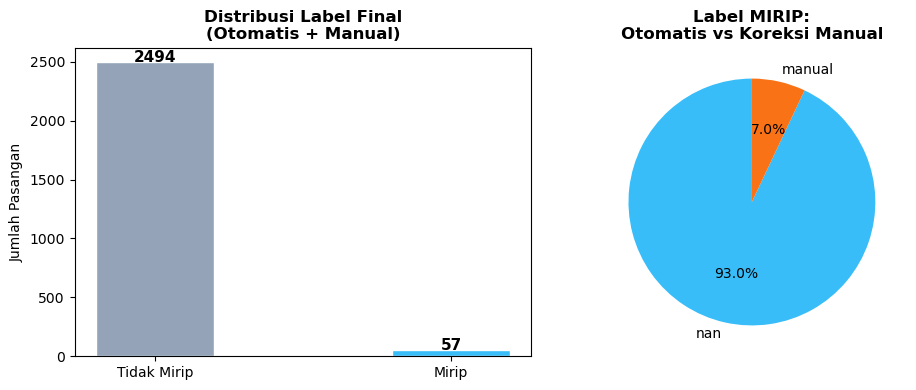


✅ Label final siap dipakai untuk training XGBoost (cell B)!


In [13]:
# Hitung koreksi vs setuju
total_spot   = min(10, (pairs_df['sim_paket']>=0.8).sum())
total_koreksi = len([k for k in koreksi_manual if k[1] != pairs_df.loc[k[0],'label']])
total_setuju  = total_spot - len(koreksi_manual)

print('=' * 55)
print('      REKAP VALIDASI MANUAL SPOT CHECK')
print('=' * 55)
print(f'  Total pasang dicek manual     : {total_spot}')
print(f'  Setuju dengan label otomatis  : {total_setuju + (len(koreksi_manual) - total_koreksi)}')
print(f'  Dikoreksi                     : {total_koreksi}')
print(f'  Akurasi label otomatis        : {((total_spot - total_koreksi)/total_spot*100):.1f}%')
print('=' * 55)

# Visualisasi label otomatis vs akhir
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Label distribution sebelum & sesudah
label_counts = pairs_df['label'].value_counts().rename({0:'Tidak Mirip',1:'Mirip'})
manual_counts = pairs_df[pairs_df['label_source']=='manual']['label'].value_counts().rename({0:'Tidak Mirip',1:'Mirip'})

axes[0].bar(label_counts.index, label_counts.values, color=['#94a3b8','#38bdf8'], width=0.4, edgecolor='white')
for i,(k,v) in enumerate(label_counts.items()):
    axes[0].text(i, v+0.2, str(v), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Distribusi Label Final\n(Otomatis + Manual)', fontweight='bold')
axes[0].set_ylabel('Jumlah Pasangan')

# Pie: otomatis vs manual
src_counts = pairs_df[pairs_df['label']==1]['label_source'].value_counts()
if len(src_counts) > 0:
    axes[1].pie(src_counts.values, labels=src_counts.index,
                autopct='%1.1f%%', startangle=90,
                colors=['#38bdf8','#f97316'])
    axes[1].set_title('Label MIRIP:\nOtomatis vs Koreksi Manual', fontweight='bold')
else:
    axes[1].text(0.5,0.5,'Belum ada koreksi manual',ha='center',va='center',transform=axes[1].transAxes)
    axes[1].set_title('Label MIRIP: Otomatis vs Manual', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n✅ Label final siap dipakai untuk training XGBoost (cell B)!')


---
## 🤖 Klasifikasi XGBoost
### Training + 5-Fold Cross Validation

In [14]:
features = ['sim_paket','sim_uraian','metode_match','pagu_ratio']
X = pairs_df[features].values
y = pairs_df['label'].values

scale_pos = (y==0).sum() / max(1,(y==1).sum())
print(f'scale_pos_weight = {scale_pos:.2f} (handle class imbalance)')

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42
)

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=cv)

print('\n=== Classification Report (5-Fold CV) ===')
print(classification_report(y, y_pred, target_names=['Tidak Mirip','Mirip']))


scale_pos_weight = 43.75 (handle class imbalance)

=== Classification Report (5-Fold CV) ===
              precision    recall  f1-score   support

 Tidak Mirip       1.00      1.00      1.00      2494
       Mirip       0.91      0.93      0.92        57

    accuracy                           1.00      2551
   macro avg       0.96      0.96      0.96      2551
weighted avg       1.00      1.00      1.00      2551



### Train Final Model & Confusion Matrix

Total predicted MIRIP: 58


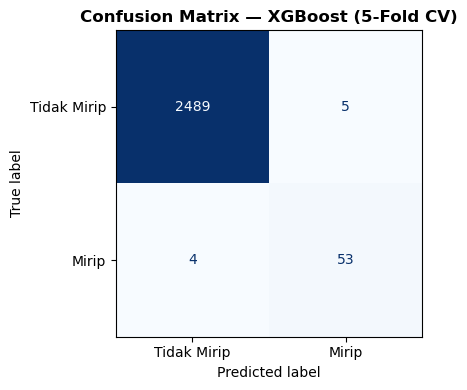

In [15]:
model.fit(X, y)
pairs_df['pred_label'] = model.predict(X)
pairs_df['pred_proba'] = model.predict_proba(X)[:,1]

mirip = pairs_df[pairs_df['pred_label']==1].copy()
print(f'Total predicted MIRIP: {len(mirip)}')

fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Tidak Mirip','Mirip']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost (5-Fold CV)', fontweight='bold')
plt.tight_layout()
plt.show()


### Feature Importance

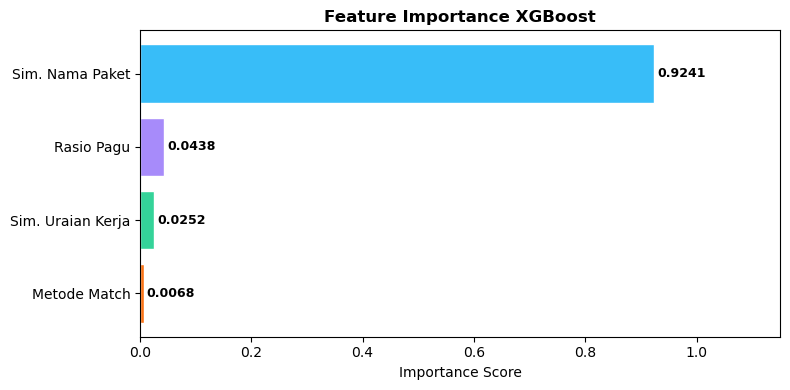

          Feature  Importance Bobot WS
     Metode Match    0.006840     0.15
Sim. Uraian Kerja    0.025234     0.35
       Rasio Pagu    0.043840        -
  Sim. Nama Paket    0.924085      0.5


In [16]:
fi_df = pd.DataFrame({
    'Feature'   : ['Sim. Nama Paket','Sim. Uraian Kerja','Metode Match','Rasio Pagu'],
    'Importance': model.feature_importances_,
    'Bobot WS'  : [W_PAKET, W_URAIAN, W_METODE, '-']
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8,4))
colors = ['#f97316','#34d399','#a78bfa','#38bdf8']
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white')
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Feature Importance XGBoost', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, 1.15)
plt.tight_layout()
plt.show()
print(fi_df.to_string(index=False))


---
## 📊 Analisis & Visualisasi Anomali
### Hitung Anomali

In [17]:
mirip['pagu_selisih_pct'] = mirip.apply(
    lambda r: abs(r.pagu_a - r.pagu_b) / max(r.pagu_a, r.pagu_b) * 100, axis=1)

budget_anomaly = mirip[mirip['pagu_selisih_pct'] > BUDGET_ANOMALY_PCT].copy()
metode_anomaly = mirip[mirip['metode_match'] == 0].copy()

print(f'Mirip + selisih anggaran > {BUDGET_ANOMALY_PCT}% : {len(budget_anomaly)} pasang')
print(f'Mirip + metode berbeda          : {len(metode_anomaly)} pasang')


Mirip + selisih anggaran > 50% : 15 pasang
Mirip + metode berbeda          : 2 pasang


### Scatter Plot Anomali Anggaran

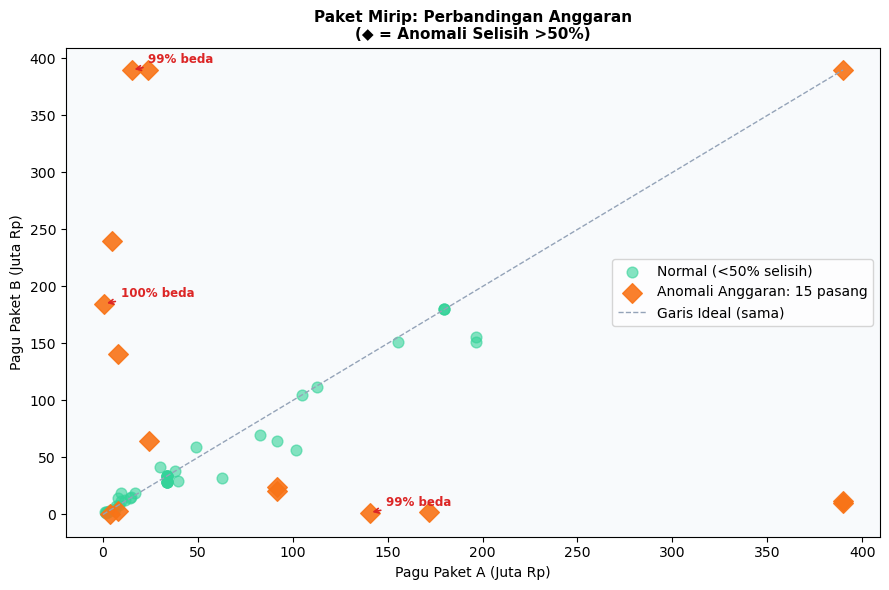

In [18]:
cap_val = mirip[['pagu_a','pagu_b']].quantile(0.95).max()
plot_data        = mirip.copy()
plot_data['pa_jt'] = plot_data['pagu_a'].clip(upper=cap_val) / 1e6
plot_data['pb_jt'] = plot_data['pagu_b'].clip(upper=cap_val) / 1e6
is_anom          = plot_data['pagu_selisih_pct'] > BUDGET_ANOMALY_PCT

fig, ax = plt.subplots(figsize=(9,6))
ax.set_facecolor('#f8fafc')

ax.scatter(plot_data.loc[~is_anom,'pa_jt'], plot_data.loc[~is_anom,'pb_jt'],
           alpha=0.6, s=60, color='#34d399', label='Normal (<50% selisih)')
ax.scatter(plot_data.loc[is_anom,'pa_jt'], plot_data.loc[is_anom,'pb_jt'],
           alpha=0.9, s=100, color='#f97316',
           label=f'Anomali Anggaran: {is_anom.sum()} pasang', marker='D')

max_v = cap_val/1e6
ax.plot([0,max_v],[0,max_v],'--',color='#94a3b8',linewidth=1,label='Garis Ideal (sama)')

top3 = plot_data[is_anom].nlargest(3,'pagu_selisih_pct')
for _, row in top3.iterrows():
    ax.annotate(f'{row["pagu_selisih_pct"]:.0f}% beda',
                (row['pa_jt'], row['pb_jt']),
                xytext=(12,5), textcoords='offset points',
                color='#dc2626', fontsize=8.5, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.2))

ax.set_xlabel('Pagu Paket A (Juta Rp)', fontsize=10)
ax.set_ylabel('Pagu Paket B (Juta Rp)', fontsize=10)
ax.set_title('Paket Mirip: Perbandingan Anggaran\n(◆ = Anomali Selisih >50%)',
             fontweight='bold', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()


### Anomali Metode Pengadaan

In [19]:
if len(metode_anomaly) > 0:
    print(f'Ditemukan {len(metode_anomaly)} pasang MIRIP dengan metode BERBEDA:\n')
    for _, row in metode_anomaly.iterrows():
        print(f'  Paket A  : {str(row["paket_a"])[:70]}')
        print(f'  Paket B  : {str(row["paket_b"])[:70]}')
        print(f'  Metode   : {row["metode_a"]}  ↔  {row["metode_b"]}')
        print(f'  Pagu     : Rp {row["pagu_a"]:,.0f}  ↔  Rp {row["pagu_b"]:,.0f}')
        print(f'  Sim Paket: {row["sim_paket"]:.2f} | Proba Mirip: {row["pred_proba"]:.2f}')
        print()
else:
    print('Tidak ada pasang mirip dengan metode berbeda pada sample ini.')


Ditemukan 2 pasang MIRIP dengan metode BERBEDA:

  Paket A  : Belanja Pemeliharaan Alat Angkutan-Alat Angkutan Darat Bermotor-Kendar
  Paket B  : Belanja Pemeliharaan Alat Angkutan-Alat Angkutan Darat Bermotor-Kendar
  Metode   : Dikecualikan  ↔  Pengadaan Langsung
  Pagu     : Rp 91,750,000  ↔  Rp 24,282,800
  Sim Paket: 0.84 | Proba Mirip: 1.00

  Paket A  : Belanja Pemeliharaan Alat Angkutan-Alat Angkutan Darat Bermotor-Kendar
  Paket B  : Belanja Pemeliharaan Alat Angkutan-Alat Angkutan Darat Bermotor-Kendar
  Metode   : Pengadaan Langsung  ↔  Dikecualikan
  Pagu     : Rp 24,282,800  ↔  Rp 64,800,000
  Sim Paket: 0.80 | Proba Mirip: 1.00



### Distribusi Similarity & Hasil Klasifikasi

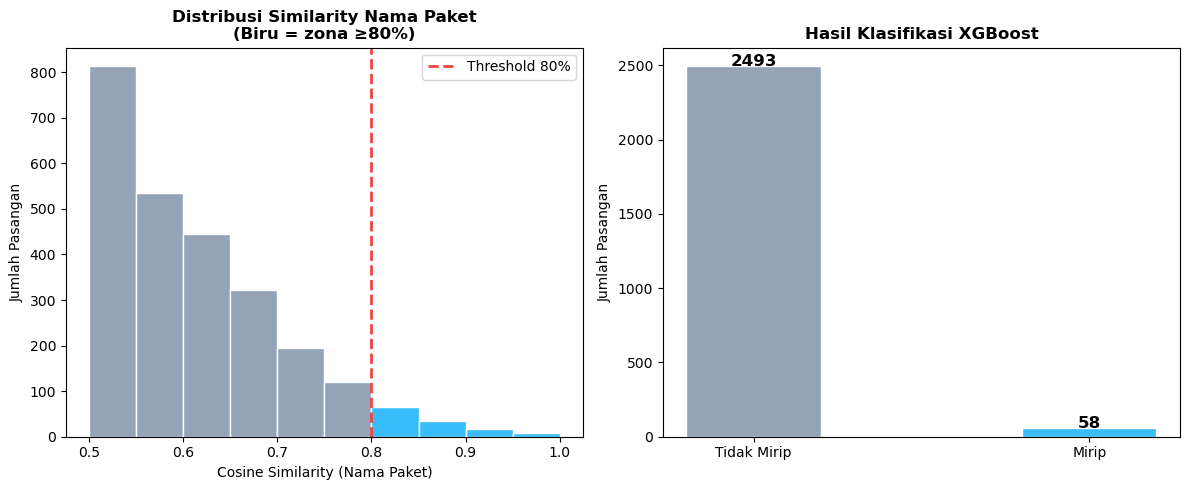

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram similarity
bins = np.arange(0.5, 1.05, 0.05)
n_hist, _, patches = axes[0].hist(pairs_df['sim_paket'], bins=bins, edgecolor='white')
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor('#38bdf8' if left >= 0.8 else '#94a3b8')
axes[0].axvline(0.8, color='#ef4444', lw=2, ls='--', label='Threshold 80%')
axes[0].set_xlabel('Cosine Similarity (Nama Paket)')
axes[0].set_ylabel('Jumlah Pasangan')
axes[0].set_title('Distribusi Similarity Nama Paket\n(Biru = zona ≥80%)', fontweight='bold')
axes[0].legend()

# Bar hasil XGBoost
label_counts = pairs_df['pred_label'].value_counts().rename({0:'Tidak Mirip',1:'Mirip'})
bar_colors = ['#94a3b8','#38bdf8']
bars = axes[1].bar(label_counts.index, label_counts.values,
                   color=bar_colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, label_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3, str(val),
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Hasil Klasifikasi XGBoost', fontweight='bold')
axes[1].set_ylabel('Jumlah Pasangan')

plt.tight_layout()
plt.show()


---
## 💾 Export Hasil

In [ ]:
mirip.to_csv('hasil_mirip_final.csv', index=False)
budget_anomaly.to_csv('anomali_anggaran.csv', index=False)
metode_anomaly.to_csv('anomali_metode.csv', index=False)
pairs_df.to_csv('semua_pairs_labeled.csv', index=False)

print('✅ Export selesai!')
print(f'  hasil_mirip_final_new.csv   → {len(mirip)} pasang mirip')
print(f'  anomali_anggaran_new.csv    → {len(budget_anomaly)} pasang anomali anggaran')
print(f'  anomali_metode_new.csv      → {len(metode_anomaly)} pasang anomali metode')
print(f'  semua_pairs_labeled_new.csv → {len(pairs_df)} semua pasang (≥0.5 sim)')


✅ Export selesai!
  hasil_mirip_final_new.csv   → 58 pasang mirip
  anomali_anggaran_new.csv    → 15 pasang anomali anggaran
  anomali_metode_new.csv      → 2 pasang anomali metode
  semua_pairs_labeled_new.csv → 2551 semua pasang (≥0.5 sim)
